In [20]:
import PeterChurchillFunctions as Function
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import erf
import statsmodels.api as sm
from scipy.odr import ODR, Model, RealData

In [21]:
# --- Fitting functions ---
def TLS_fit(X, Y):
    """Total Least Squares using eigenvalues and eigenvectors."""
    Xc, Yc = X - X.mean(), Y - Y.mean()
    cov = np.cov(Xc, Yc)
    eigvals, eigvecs = np.linalg.eig(cov)
    v = eigvecs[:, np.argmax(eigvals)]
    slope = v[1] / v[0]
    intercept = Y.mean() - slope * X.mean()
    return slope, intercept


def TLS_SVD_fit(X, Y):
    """Total Least Squares using SVD."""
    Xc, Yc = X - X.mean(), Y - Y.mean()
    Z = np.column_stack((Xc, Yc))
    U, S, Vt = np.linalg.svd(Z, full_matrices=False)
    v = Vt.T[:, 0]  # principal direction
    slope = v[1] / v[0]
    intercept = Y.mean() - slope * X.mean()
    return slope, intercept

def ODR_fit(X, Y):
    """Orthogonal Distance Regression (ODR)."""
    mask = np.isfinite(X) & np.isfinite(Y)
    X, Y = X[mask], Y[mask]

    def linear_func(B, x):
        return B[0] * x + B[1]

    sx = np.std(X) * 0.05
    sy = np.std(Y) * 0.05

    model = Model(linear_func)
    data = RealData(X, Y, sx=sx, sy=sy)
    odr = ODR(data, model, beta0=[1.0, 0.0])
    out = odr.run()
    slope, intercept = out.beta
    return slope, intercept


def OLS_fit(X, Y):
    """Ordinary Least Squares regression"""
    mask = np.isfinite(X) & np.isfinite(Y)
    X, Y = X[mask], Y[mask]

    slope = np.sum(X - X.mean()) * (Y - Y.mean()) / np.sum((X - X.mean()) ** 2)
    intercept = Y.mean() - slope * X.mean()
    return slope, intercept


In [22]:
NorPath = "/share/sabl0586/all_stations_NorESM_OsloAero_prcp2szdst_f19_f19_noresmv211_corr_ilevall_levs_4Peter.nc"
ECPath = "/share/sabl0586/all_stations_EC-Earth_PRCP2SZDST_ilevall_levs_4Peter.nc"
station='SMR-II'
VarList = ['FREQL', 'AWNC', 'WSUB', 'T', ]
ifs_vars = ['var130','var131','var132','var20','var21','var22','var248']
ifs_vars_names = ['temp','U','V','CDNC','re_liq','Liquid_Cloud_time','Cloud_Frac']
x = xr.DataArray(np.logspace(-0.5,3, num=200), dims =['D'], coords= {'D':np.logspace(-0.5,3, num=200)})
Nor_ds, Nor_PNSD_ds = Function.NorESMExtract(NorPath, station, VarList, x)
def DropletNumber(Data):
    Data['CDNC'] = Data['AWNC']/Data['FREQL']
    return 
DropletNumber(Nor_ds)

radii = np.arange(20,51)
CCN_ds = NorERF(Nor_PNSD_ds, radii)

In [23]:
def TLSbootstrap(x, y, n_bootstrap=1000, random_state=None, plot=True):
    """
    Perform Total Least Squares regression on log10-transformed data using Singular Value Decomposition,
    with optional bootstrapped confidence intervals and plotting.

    Parameters
    ----------
    x, y : array-like or xarray.DataArray
        Input data (e.g., CCN and Nd).
    n_bootstrap : int, default=1000
        Number of bootstrap resamples.
    random_state : int or None
        Random seed for reproducibility.
    plot : bool, default=True
        If True, produce a hexbin plot with regression line. 
        If False, skip plotting and just return results.

    Returns
    -------
    results : dict
        Contains slope, intercept, correlation R, slope_CI, intercept_CI.
    (fig, ax) : matplotlib Figure and Axes
        Only returned if plot=True. Otherwise, returns (None, None).
    """

    # --- Convert to numpy and clean ---
    x = np.asarray(x).ravel()
    y = np.asarray(y).ravel()
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    # --- Log10-transform ---
    X = np.log10(x)
    Y = np.log10(y)
    n = len(X)
    rng = np.random.default_rng(random_state)

    # --- Compute main fit ---
    slope, intercept = TLS_fit(X, Y)
    R = np.corrcoef(X, Y)[0, 1]

    # --- Bootstrap resampling ---
    slopes = np.empty(n_bootstrap)
    intercepts = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        idx = rng.integers(0, n, n)  # sample with replacement
        slopes[i], intercepts[i] = TLS_fit(X[idx], Y[idx])

    slope_CI = np.percentile(slopes, [2.5, 97.5])
    intercept_CI = np.percentile(intercepts, [2.5, 97.5])

    # --- Print summary ---
    print(f"TLS slope = {slope:.3f} (95% CI {slope_CI[0]:.3f}, {slope_CI[1]:.3f})")
    print(f"Intercept = {intercept:.3f} (95% CI {intercept_CI[0]:.3f}, {intercept_CI[1]:.3f})")
    print(f"Correlation R = {R:.3f}")

    results = {
        "slope": slope,
        "intercept": intercept,
        "R": R,
        "slope_CI": slope_CI,
        "intercept_CI": intercept_CI
    }

    # --- Optional plotting ---
    fig, ax = None, None
    if plot:
        fig, ax = plt.subplots(figsize=(6, 6))
        hb = ax.hexbin(
            x, y, gridsize=50, bins='log',
            xscale='log', yscale='log',
            cmap='inferno', mincnt=1
        )

        lims = [1, 1e4]
        ax.set_xlim(lims)
        ax.set_ylim(lims)

        x_fit = np.array(lims)
        y_fit = 10 ** (intercept + slope * np.log10(x_fit))
        ax.plot(
            x_fit, y_fit, 'r-', lw=2,
            label=f"TLS slope={slope:.2f} [95% CI {slope_CI[0]:.2f}, {slope_CI[1]:.2f}]"
        )
        ax.plot(lims, lims, 'k--', lw=1, label='1:1 line')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('CCN [cm$^{-3}$]')
        ax.set_ylabel('Nd [cm$^{-3}$]')
        ax.legend()
        ax.set_aspect('equal', adjustable='box')
        plt.colorbar(hb, ax=ax, label='Counts')

    return results, (fig, ax)


TLS slope = 1.100 (95% CI 1.070, 1.126)
Intercept = -0.756 (95% CI -0.814, -0.689)
Correlation R = 0.529


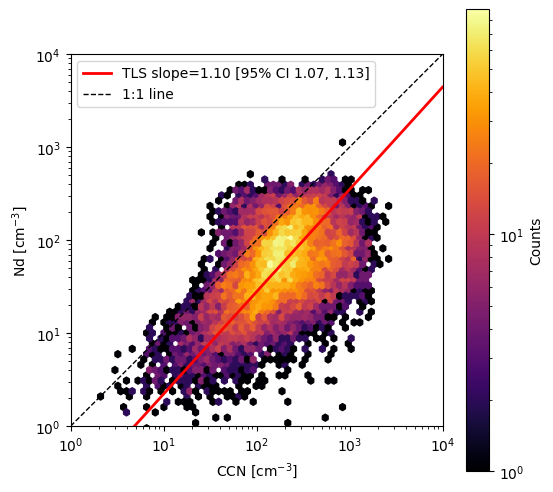

In [24]:
results, (fig, ax) = TLSbootstrap(
    CCN_ds.sel(radius=35),
    Nor_ds['CDNC'],
    n_bootstrap=500,  # faster
    random_state=42,
    plot = True
)
plt.show()

In [25]:
x = CCN_ds.sel(radius=35)
y = Nor_ds['CDNC']

x = np.asarray(x).ravel()
y = np.asarray(y).ravel()
mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
x, y = x[mask], y[mask]
print(len(x))
# --- Log10-transform ---
X = np.log10(x)
Y = np.log10(y)
n = len(X)

# --- Define helper function for TLS ---

Xc, Yc = X - X.mean(), Y - Y.mean()
cov = np.cov(Xc, Yc)
eigvals, eigvecs = np.linalg.eig(cov)
v = eigvecs[:, np.argmax(eigvals)]
slope = v[1] / v[0]
intercept = Y.mean() - slope * X.mean()


14209


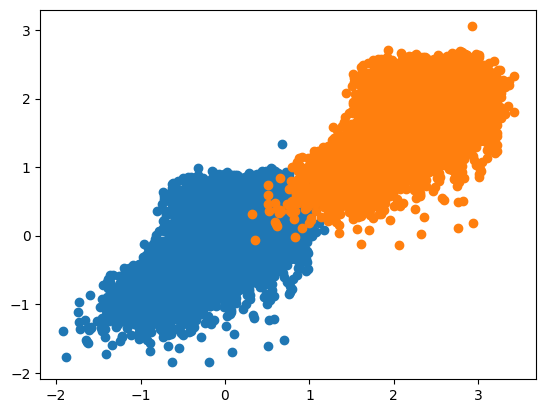

In [26]:
plt.scatter(Xc,Yc)

plt.scatter(X,Y)


In [27]:
eigvecs

array([[-0.74002847, -0.67257555],
       [ 0.67257555, -0.74002847]])

In [28]:
# --- Main plotting function ---
def CompareFits(CCN, Nd):
    """
    Plot OLS, TLS, and ODR regression lines over log–log hexbin.
    """
    # Flatten and clean
    x = np.ravel(CCN)
    y = np.ravel(Nd)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0) & (y > 0)
    x, y = x[mask], y[mask]

    # Log10 transform
    X_log, Y_log = np.log10(x), np.log10(y)

    # --- OLS ---
    res = stats.linregress(X_log, Y_log)
    ols_slope, ols_intercept = res.slope, res.intercept

    # --- TLS (SVD) ---
    tls_slope, tls_intercept = TLS_SVD_fit(X_log, Y_log)

    # --- ODR ---
    odr_slope, odr_intercept = ODR_fit(X_log, Y_log)

    # --- Print fits ---
    print(f"OLS: slope = {ols_slope:.3f}, intercept = {ols_intercept:.3f}")
    print(f"TLS: slope = {tls_slope:.3f}, intercept = {tls_intercept:.3f}")
    print(f"ODR: slope = {odr_slope:.3f}, intercept = {odr_intercept:.3f}")

    # --- Plot ---
    fig, ax = plt.subplots(figsize=(6,6))

    hb = ax.hexbin(
        x, y,
        gridsize=50, bins='log',
        xscale='log', yscale='log',
        cmap='inferno', mincnt=1
    )

    # Regression lines
    lims = np.array([1, 1e4])
    x_fit = lims
    ax.plot(
        x_fit, 10 ** (ols_intercept + ols_slope * np.log10(x_fit)),
        'r-', lw=2, label=f'OLS (slope={ols_slope:.2f})'
    )
    ax.plot(
        x_fit, 10 ** (tls_intercept + tls_slope * np.log10(x_fit)),
        'b--', lw=2, label=f'TLS (slope={tls_slope:.2f})'
    )
    ax.plot(
        x_fit, 10 ** (odr_intercept + odr_slope * np.log10(x_fit)),
        'g-.', lw=2, label=f'ODR (slope={odr_slope:.2f})'
    )

    # 1:1 line
    ax.plot(lims, lims, 'k:', lw=1.5, label='1:1')

    # Labels and formatting
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_aspect('equal', adjustable='box')
    ax.set_xlabel('CCN [cm$^{-3}$]')
    ax.set_ylabel('Nd [cm$^{-3}$]')
    ax.grid(True, which='both', ls=':')
    cb = fig.colorbar(hb, ax=ax, label='Counts')
    ax.legend()
    plt.tight_layout()

    return fig, ax

OLS: slope = 0.557, intercept = 0.465
TLS: slope = 1.100, intercept = -0.756
ODR: slope = 1.052, intercept = -0.647


(<Figure size 600x600 with 2 Axes>,
 <Axes: xlabel='CCN [cm$^{-3}$]', ylabel='Nd [cm$^{-3}$]'>)

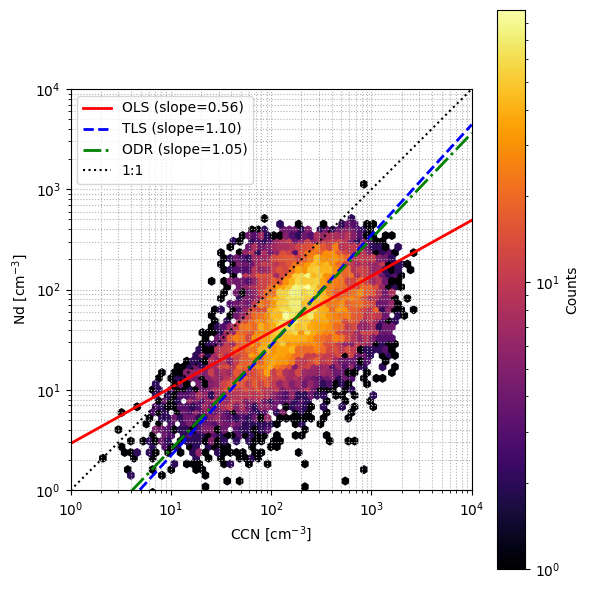

In [29]:
CompareFits(CCN_ds.sel(radius = 35),Nor_ds['CDNC'] )

In [ ]:
Nor_ds['CDNC']